# День 08. Упражнение 05
# Кластеризация

## 0. Импорты

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
regression = '../../datasets/regression.csv'

## 1. Предобработка

1. Прочитай файл [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) в DataFrame.
2. Удали колонку `pageviews`, мы будем кластеризовать пользователей только по количеству коммитов и их средней разнице.

In [2]:
df = pd.read_csv(regression)
df.drop(columns='pageviews', inplace=True)
df

,uid,num_commits,AVG(diff)
0,user_1,62,-64.400000
1,user_10,20,-74.800000
2,user_14,61,-159.000000
3,user_17,51,-61.600000
4,user_18,5,-5.666667
5,user_19,118,-98.750000
6,user_21,65,-95.500000
7,user_25,79,-92.600000
8,user_28,60,-86.400000
9,user_3,18,-105.400000


In [3]:
X = df.drop(columns= 'uid')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   uid          29 non-null     str    
 1   num_commits  29 non-null     int64  
 2   AVG(diff)    29 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 828.0 bytes


## 2. KMeans

1. Ознакомься с документацией и разберись, как работает этот алгоритм.
2. Используй этот алгоритм для создания кластеров с параметрами `random_state=21` и `n_clusters=3`.
3. Визуализируй данные на `scatter plot`.
4. Попробуй разные значения `n_clusters` и посмотри, как изменится твой график.
5. Вычисли `silhouette_score` (см. документацию по метрике).

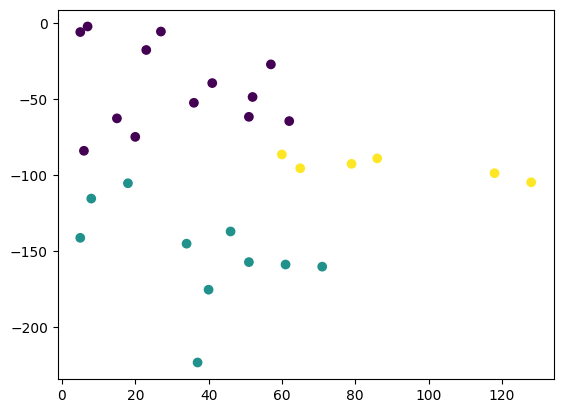

In [4]:
kmeans = KMeans(n_clusters=3, random_state=21)
clusters = kmeans.fit_predict(X)
plt.scatter(X['num_commits'], X['AVG(diff)'], c = clusters)
plt.show()

In [5]:
score = silhouette_score(X, clusters)
score

0.4454402135233297

## 3. DBSCAN

1. Ознакомься с документацией и разберись, как работает этот алгоритм.
2. Используй этот алгоритм для создания кластеров с параметрами `eps=20` и `min_samples=2`.
3. Визуализируй данные на `scatter plot`.
4. Попробуй разные значения `eps` и `min_samples` и посмотри, как изменится твой график.
5. Вычисли `silhouette_score` (см. документацию по метрике).

In [6]:
dbs = DBSCAN(eps=20, min_samples=2)

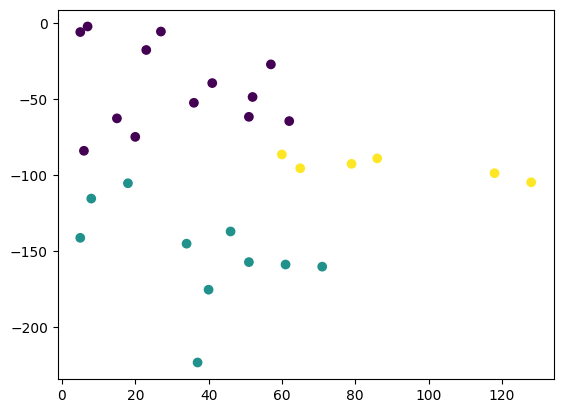

In [7]:
clusters - dbs.fit_predict(X)
plt.scatter(X['num_commits'], X['AVG(diff)'], c = clusters)
plt.show()

In [8]:
score = silhouette_score(X, clusters)
score

0.4454402135233297

## 4. Иерархическая кластеризация (AgglomerativeClustering)

1. Используй этот алгоритм для создания кластеров с параметром `n_clusters=5`.
2. Визуализируй данные на `scatter plot`.
3. Попробуй разные значения `n_clusters` и посмотри, как изменится твой график.
4. Вычисли `silhouette_score`.
5. Визуализируй `dendrogram`.

In [9]:
AC = AgglomerativeClustering(n_clusters=5)

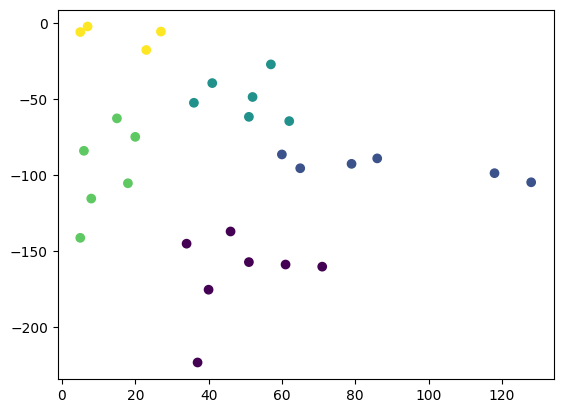

In [10]:
clusters = AC.fit_predict(X)
plt.scatter(X['num_commits'], X['AVG(diff)'], c = clusters)

In [11]:
score = silhouette_score(X, clusters)
score

0.46383015199381467

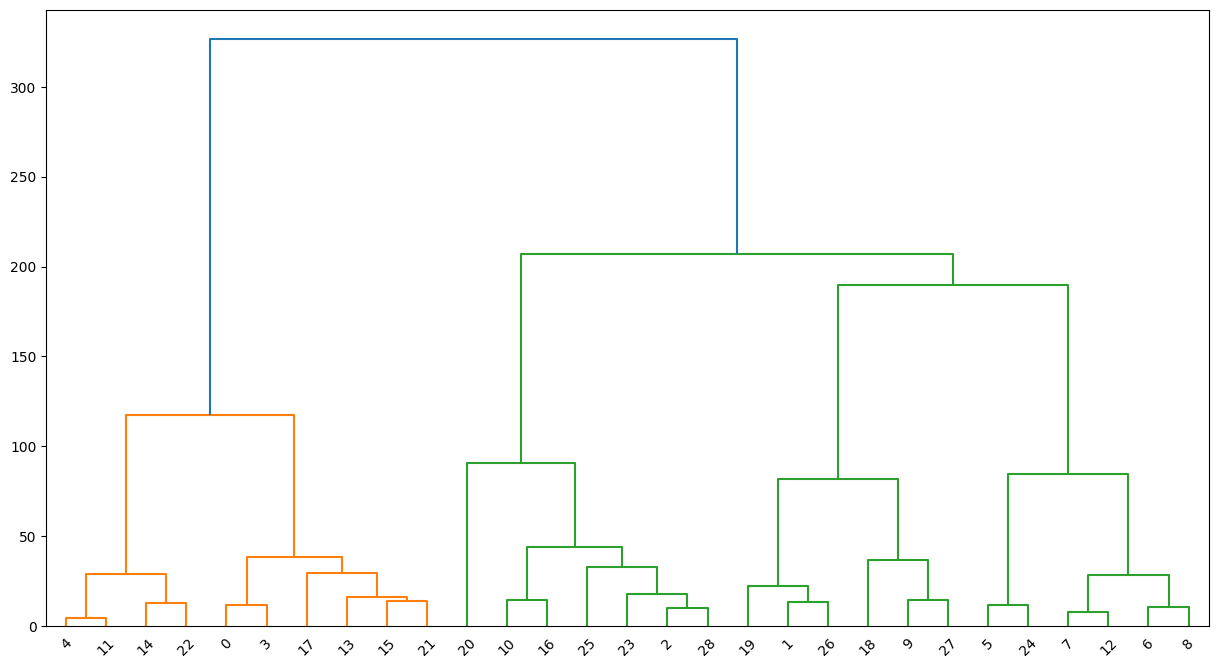

In [12]:
linked = linkage(X, method="ward")
plt.figure(figsize=(15, 8))
dendrogram(linked)
plt.show()

## 5. Функция

Напиши функцию, которая:
1. Принимает аргументы: класс модели кластеризации, её параметры, имя параметра для оптимизации и диапазон значений этого параметра.
2. Перебирает разные значения из заданного диапазона и вычисляет `silhouette_score` для каждого значения.
3. Определяет лучшее значение параметра в диапазоне.
4. Возвращает два подграфика:

- первый показывает, как `silhouette_score` меняется в зависимости от значения параметра;
- второй визуализирует данные на `scatter plot` с использованием модели кластеризации с лучшим найденным значением параметра.

In [13]:
def optimize(model_class, optimize_param, rng, X, base_params=None):
    if base_params is None:
        base_params = {}
        
    scores = []
    best_score = 0
    best_param = None
    best_clusters = None

    for value in rng:
        params = base_params.copy()
        params[optimize_param] = value
        model = model_class(**params)
        clusters = model.fit_predict(X)
        if len(set(clusters)) < 2:
            scores.append(0)
            continue

        score = silhouette_score(X, clusters)
        scores.append(score)

        if score > best_score:
            best_score = score
            best_clusters = clusters
            best_param = value

    fig = plt.figure(figsize=(15, 8))
    ax1 = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)

    ax1.plot(rng, scores)
    ax1.set_xlabel(optimize_param)
    ax1.set_ylabel("score")
    ax1.set_title(f"Best {optimize_param}: {best_param}")

    ax2.scatter(X.iloc[:, 0], X.iloc[:, 1], c=best_clusters)
    ax2.set_xlabel(X.columns[0])
    ax2.set_ylabel(X.columns[1])
    ax2.set_title("Best clustering")

    plt.show()

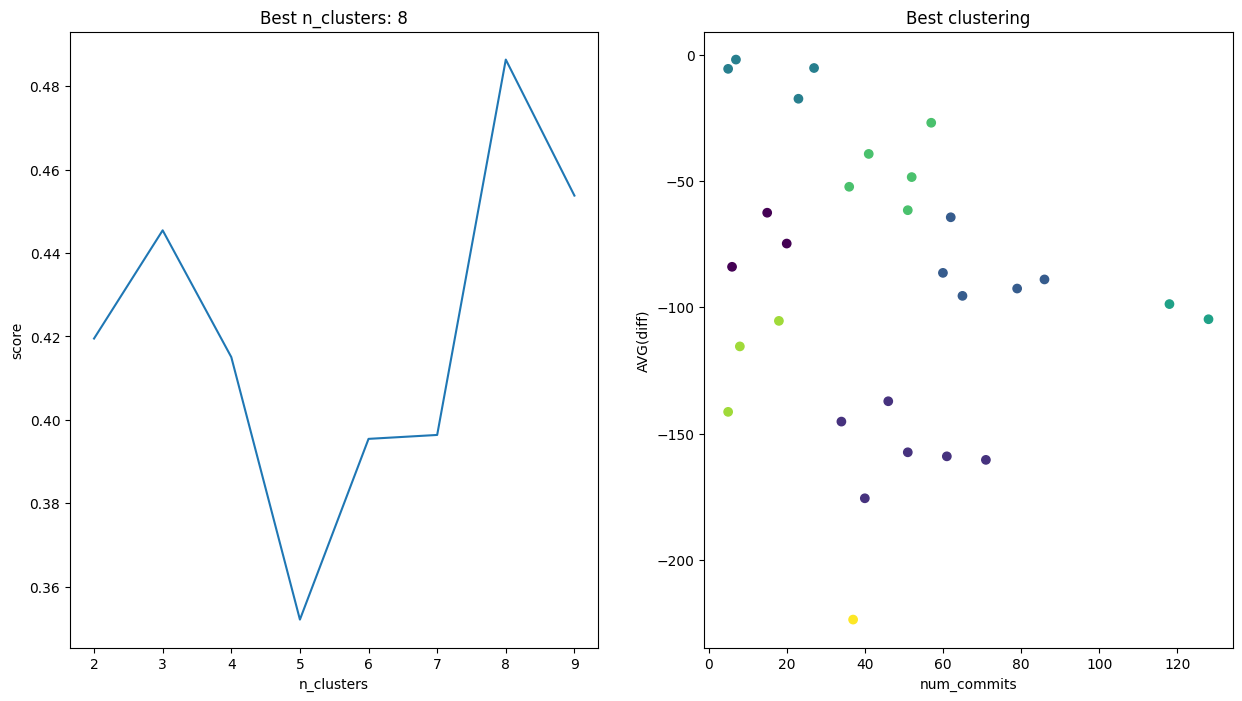

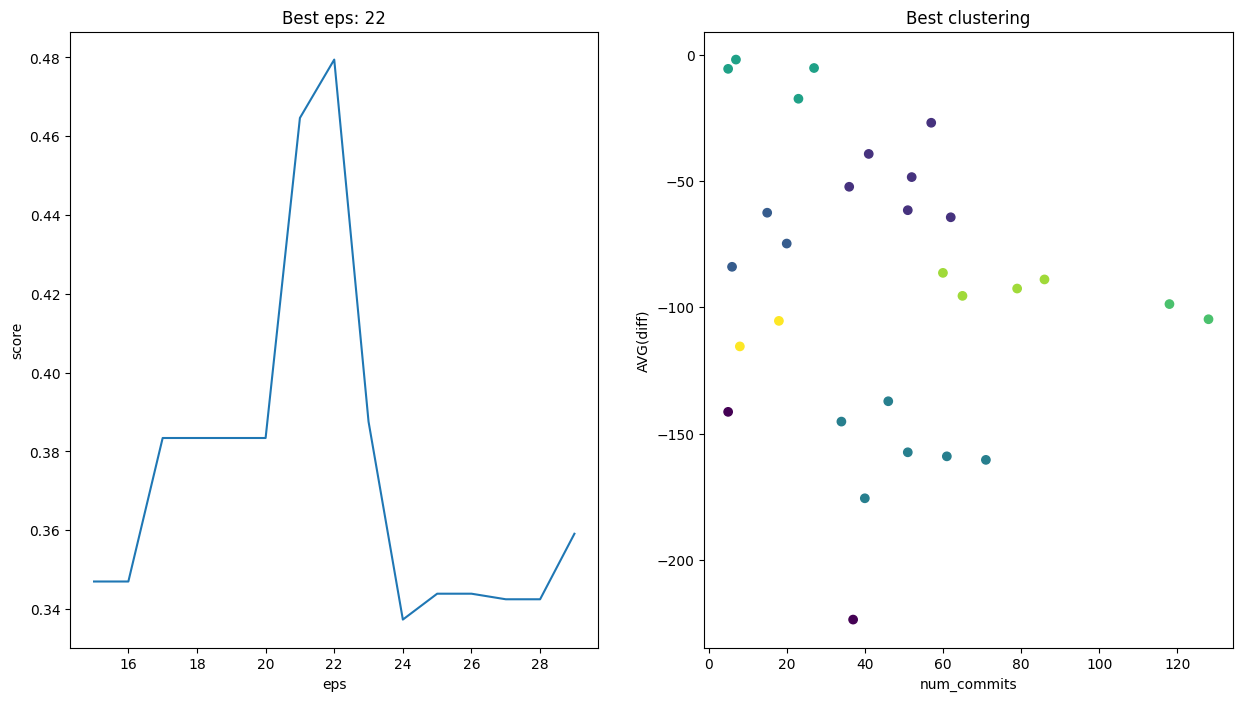

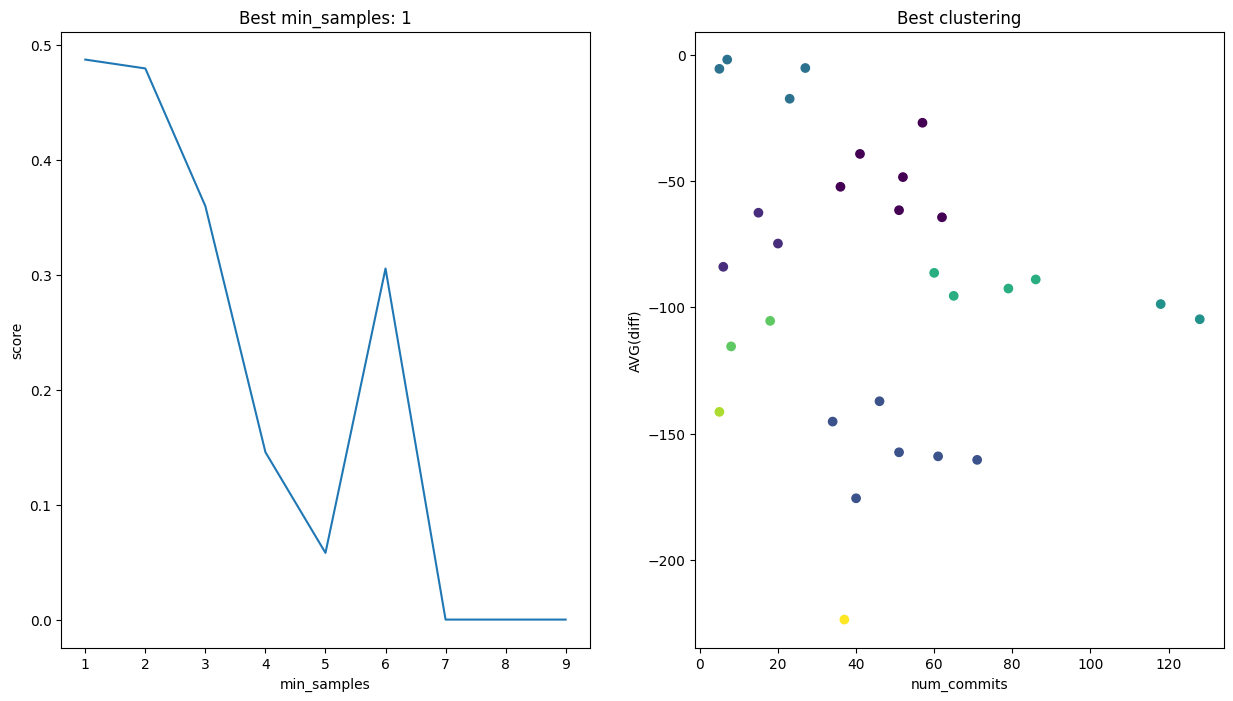

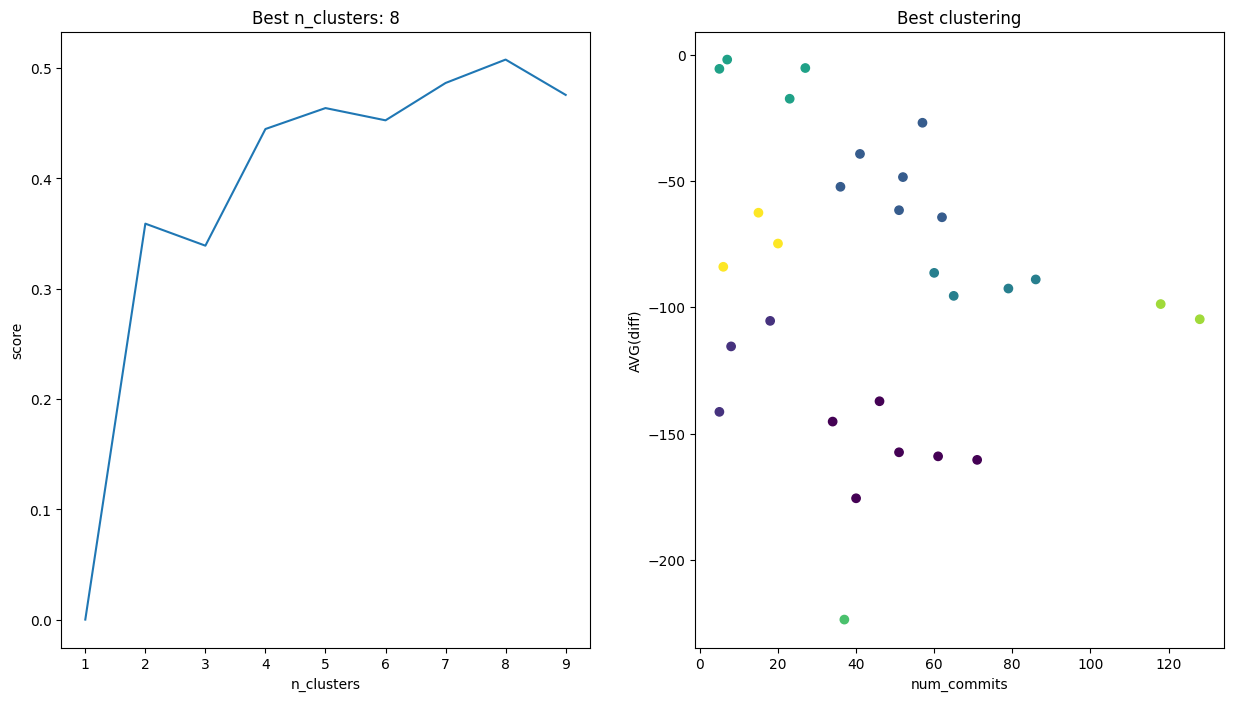

In [14]:
optimizations = [
    (KMeans, {"random_state": 21}, "n_clusters", range(2, 10)),
    (DBSCAN, {"min_samples": 2}, "eps", range(15, 30)),
    (DBSCAN, {"eps": 22}, "min_samples", range(1, 10)),
    (AgglomerativeClustering, {}, "n_clusters", range(1, 10)),
]

for model_class, base_params, opt_param, rng in optimizations:
    optimize(
        model_class=model_class,
        base_params=base_params,
        optimize_param=opt_param,
        rng=rng,
        X=X
    )